Phase 1 : Save to Drive + Load + Preview

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/unemployment-analysis-india'

os.makedirs(f'{base}/data', exist_ok=True)
os.makedirs(f'{base}/notebooks', exist_ok=True)
os.makedirs(f'{base}/outputs', exist_ok=True)

print("All folders created!")
print(os.listdir(base))

Mounted at /content/drive
All folders created!
['data', 'notebooks', 'outputs']


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly folium nltk wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries ready!")

All libraries ready!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving unemployment_education.csv to unemployment_education.csv
Saving unemployment_India.csv to unemployment_India.csv


In [4]:
import shutil

base = '/content/drive/MyDrive/unemployment-analysis-india/data'

# Save all uploaded files to Drive
for filename in uploaded.keys():
    shutil.copy(filename, f'{base}/{filename}')
    print(f"Saved: {filename}")

print("\nFiles in data folder:")
print(os.listdir(base))

Saved: unemployment_education.csv
Saved: unemployment_India.csv

Files in data folder:
['unemployment_education.csv', 'unemployment_india.csv', '.ipynb_checkpoints', 'mgnregs_data.csv', 'unemployment_clean.csv', 'mgnregs_state_clean.csv', 'mgnregs_district_clean.csv', 'india_global_unemployment.csv', 'unemployment_India.csv']


In [5]:
from google.colab import files
uploaded2 = files.upload()

Saving mgnregs_data.csv to mgnregs_data.csv


In [6]:
import shutil
shutil.copy('mgnregs_data.csv', '/content/drive/MyDrive/unemployment-analysis-india/data/mgnregs_data.csv')

mgnregs = pd.read_csv('/content/drive/MyDrive/unemployment-analysis-india/data/mgnregs_data.csv')
print("Shape:", mgnregs.shape)
print("\nColumns:")
print(mgnregs.columns.tolist())
print("\nSample:")
print(mgnregs.head(3))

Shape: (740, 30)

Columns:
['state_name', 'district_name', 'Total No. of JobCards issued', 'Total No. of Workers', 'Total No. of Active Job Cards', 'Total No. of Active Workers', 'SC workers against active workers', 'ST workers against active workers', 'Approved Labour Budget', 'Persondays of Central Liability so far', 'SC persondays', 'ST persondays', 'Women Persondays', 'Average days of employment provided per Household', 'Average Wage rate per day per person(Rs.)', 'Total No of HHs completed 100 Days of Wage Employment', 'Total Households Worked', 'Total Individuals Worked', 'Differently abled persons worked', 'Number of GPs with NIL exp', 'Total No. of Works Takenup (New+Spill Over)', 'Number of Ongoing Works', 'Number of Completed Works', '% of NRM Expenditure(Public + Individual)', '% of Category B Works', '% of Expenditure on Agriculture & Agriculture Allied Works', 'Total Exp(Rs. in Lakhs.)', 'Wages(Rs. In Lakhs)', 'Material and skilled Wages(Rs. In Lakhs)', 'Total Adm Expendit

In [7]:
data_path = '/content/drive/MyDrive/unemployment-analysis-india/data'

# Load all 2
unemp = pd.read_csv(f'{data_path}/unemployment_india.csv')
unemp_edu = pd.read_csv(f'{data_path}/unemployment_education.csv')

print("=== UNEMPLOYMENT DATASET ===")
print("Shape:", unemp.shape)
print("Columns:", unemp.columns.tolist())
print(unemp.head(3))

print("\n=== UNEMPLOYMENT BY EDUCATION ===")
print("Shape:", unemp_edu.shape)
print("Columns:", unemp_edu.columns.tolist())
print(unemp_edu.head(3))


=== UNEMPLOYMENT DATASET ===
Shape: (768, 7)
Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  

=== UNEMPLOYMENT BY EDUCATION ===
Shape: (235, 33)
Columns: ['Country Name', 'Country Code', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002'

In [8]:
print("=== DATASET 1 COLUMNS ===")
print(unemp.columns.tolist())
print(unemp.shape)
print(unemp.head(3))

print("\n=== DATASET 2 COLUMNS ===")
print(unemp_edu.columns.tolist())
print(unemp_edu.shape)
print(unemp_edu.head(3))

=== DATASET 1 COLUMNS ===
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
(768, 7)
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  

=== DATASET 2 COLUMNS ===
['Country Name', 'Country Code', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '20

Phase 2 — Data Cleaning + Feature Engineering

In [9]:
# Clean Dataset 1 (Main Unemployment Data)

# Clean column names first - remove extra spaces
unemp.columns = unemp.columns.str.strip()

# Rename columns for easier use
unemp = unemp.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Date': 'Date',
    'Region': 'State',
    'Frequency': 'Frequency',
    'Area': 'Area'
})

# Clean text columns
unemp['State'] = unemp['State'].str.strip()
unemp['Area'] = unemp['Area'].str.strip()

# Convert date to datetime
unemp['Date'] = pd.to_datetime(unemp['Date'].str.strip(), dayfirst=True)

# Extract month and year
unemp['Year'] = unemp['Date'].dt.year
unemp['Month'] = unemp['Date'].dt.month
unemp['Month_Name'] = unemp['Date'].dt.strftime('%b')

# Drop nulls
unemp = unemp.dropna()

print("Cleaned Dataset 1 shape:", unemp.shape)
print("\nColumns:", unemp.columns.tolist())
print("\nYear range:", unemp['Year'].min(), "to", unemp['Year'].max())
print("\nUnique States:", unemp['State'].nunique())
print("\nAreas:", unemp['Area'].unique())
print("\nSample:")
print(unemp.head(5))

Cleaned Dataset 1 shape: (740, 10)

Columns: ['State', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area', 'Year', 'Month', 'Month_Name']

Year range: 2019.0 to 2020.0

Unique States: 28

Areas: ['Rural' 'Urban']

Sample:
            State       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly               3.32  12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly               5.17  12256762.0   

   Labour_Participation_Rate   Area    Year  Month Month_Name  
0                      43.24  Rural  2019.0    5.0        May  
1                      42.05  Rural  2019.0    6.0        Jun  
2                      43.50  Rural  2019.0    7.0        Jul  
3                      43.97  Rural  2019.0 

In [10]:
# Extract India from Dataset 2

# Extract only India row
india_global = unemp_edu[unemp_edu['Country Name'] == 'India'].copy()

# Melt from wide to long format
india_global = india_global.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Global_Unemployment_Rate'
)

# Clean
india_global['Year'] = india_global['Year'].astype(int)
india_global = india_global.dropna()

# Keep only years that overlap with dataset 1
india_global = india_global[india_global['Year'].isin([2019, 2020, 2021])]

print("India Global Unemployment Rate:")
print(india_global[['Year', 'Global_Unemployment_Rate']].to_string(index=False))

India Global Unemployment Rate:
 Year  Global_Unemployment_Rate
 2019                      5.27
 2020                      8.00
 2021                      5.98


In [11]:
#  Clean Unemployment Dataset

# Clean column names
unemp.columns = unemp.columns.str.strip()

# Rename columns
unemp = unemp.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Date': 'Date',
    'Region': 'State',
    'Frequency': 'Frequency',
    'Area': 'Area'
})

# Clean text
unemp['State'] = unemp['State'].str.strip()
unemp['Area'] = unemp['Area'].str.strip()

# Check what date column looks like first
print("Date column type:", unemp['Date'].dtype)
print("Sample dates:", unemp['Date'].head(5).tolist())

# Convert date safely
unemp['Date'] = pd.to_datetime(unemp['Date'], dayfirst=True, infer_datetime_format=True)

# Extract time features
unemp['Year'] = unemp['Date'].dt.year
unemp['Month'] = unemp['Date'].dt.month
unemp['Month_Name'] = unemp['Date'].dt.strftime('%b')

# Drop nulls
unemp = unemp.dropna()

print("\nCleaned Unemployment Data:")
print("Shape:", unemp.shape)
print("States:", unemp['State'].nunique())
print("Year range:", unemp['Year'].min(), "to", unemp['Year'].max())
print("Areas:", unemp['Area'].unique())
print(unemp.head(3))

Date column type: datetime64[ns]
Sample dates: [Timestamp('2019-05-31 00:00:00'), Timestamp('2019-06-30 00:00:00'), Timestamp('2019-07-31 00:00:00'), Timestamp('2019-08-31 00:00:00'), Timestamp('2019-09-30 00:00:00')]

Cleaned Unemployment Data:
Shape: (740, 10)
States: 28
Year range: 2019 to 2020
Areas: ['Rural' 'Urban']
            State       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   

   Labour_Participation_Rate   Area  Year  Month Month_Name  
0                      43.24  Rural  2019      5        May  
1                      42.05  Rural  2019      6        Jun  
2                      43.50  Rural  2019      7        Jul  


In [12]:
# Clean MGNREGS Dataset

# Clean column names
mgnregs.columns = mgnregs.columns.str.strip()

# Rename key columns for easier use
mgnregs = mgnregs.rename(columns={
    'state_name': 'State',
    'district_name': 'District',
    'Total No. of JobCards issued': 'Total_JobCards',
    'Total No. of Workers': 'Total_Workers',
    'Total No. of Active Job Cards': 'Active_JobCards',
    'Total No. of Active Workers': 'Active_Workers',
    'SC workers against active workers': 'SC_Workers',
    'ST workers against active workers': 'ST_Workers',
    'Women Persondays': 'Women_Persondays',
    'Average days of employment provided per Household': 'Avg_Employment_Days',
    'Average Wage rate per day per person(Rs.)': 'Avg_Wage_Per_Day',
    'Total No of HHs completed 100 Days of Wage Employment': 'HH_Completed_100Days',
    'Total Households Worked': 'Total_HH_Worked',
    'Total Individuals Worked': 'Total_Individuals_Worked',
    'Total Exp(Rs. in Lakhs.)': 'Total_Expenditure_Lakhs',
    'Wages(Rs. In Lakhs)': 'Wages_Lakhs',
    'Number of Completed Works': 'Completed_Works',
    'Number of Ongoing Works': 'Ongoing_Works',
    'Persondays of Central Liability so far': 'Total_Persondays',
    '% of Expenditure on Agriculture & Agriculture Allied Works': 'Agri_Expenditure_Pct'
})

# Clean state names
mgnregs['State'] = mgnregs['State'].str.strip().str.title()
mgnregs['District'] = mgnregs['District'].str.strip().str.title()

# Drop nulls
mgnregs = mgnregs.dropna(subset=['State', 'Total_Expenditure_Lakhs'])

# Calculate women participation percentage
mgnregs['Women_Participation_Pct'] = (
    mgnregs['Women_Persondays'] /
    mgnregs['Total_Persondays'] * 100
).round(2)

# Calculate scheme reach percentage
mgnregs['Scheme_Reach_Pct'] = (
    mgnregs['Active_Workers'] /
    mgnregs['Total_Workers'] * 100
).round(2)

print("Cleaned MGNREGS Data:")
print("Shape:", mgnregs.shape)
print("States:", mgnregs['State'].nunique())
print("Districts:", mgnregs['District'].nunique())
print(mgnregs.head(3))

Cleaned MGNREGS Data:
Shape: (740, 32)
States: 34
Districts: 736
                 State                  District  Total_JobCards  \
0  Andaman And Nicobar                  Nicobars            6173   
1  Andaman And Nicobar  North And Middle Andaman           18521   
2  Andaman And Nicobar             South Andaman           13726   

   Total_Workers  Active_JobCards  Active_Workers  SC_Workers  ST_Workers  \
0           9866             1007            2011           0        1678   
1          29500             6477           11920           0           0   
2          17491             3420            5016           0           0   

   Approved Labour Budget  Total_Persondays  ...  Completed_Works  \
0                   34000              5046  ...                0   
1                   76000             30487  ...               74   
2                   40000              4522  ...              227   

   % of NRM Expenditure(Public + Individual)  % of Category B Works  \
0    

In [13]:
# Create State Level MGNREGS Summary

# Aggregate district level to state level
mgnregs_state = mgnregs.groupby('State').agg(
    Total_JobCards=('Total_JobCards', 'sum'),
    Total_Workers=('Total_Workers', 'sum'),
    Active_Workers=('Active_Workers', 'sum'),
    Total_HH_Worked=('Total_HH_Worked', 'sum'),
    Total_Persondays=('Total_Persondays', 'sum'),
    Women_Persondays=('Women_Persondays', 'sum'),
    Avg_Wage_Per_Day=('Avg_Wage_Per_Day', 'mean'),
    Avg_Employment_Days=('Avg_Employment_Days', 'mean'),
    Total_Expenditure_Lakhs=('Total_Expenditure_Lakhs', 'sum'),
    Completed_Works=('Completed_Works', 'sum'),
    HH_Completed_100Days=('HH_Completed_100Days', 'sum')
).reset_index()

# Recalculate percentages at state level
mgnregs_state['Women_Participation_Pct'] = (
    mgnregs_state['Women_Persondays'] /
    mgnregs_state['Total_Persondays'] * 100
).round(2)

mgnregs_state['Scheme_Reach_Pct'] = (
    mgnregs_state['Active_Workers'] /
    mgnregs_state['Total_Workers'] * 100
).round(2)

print("State Level MGNREGS Summary:")
print("Shape:", mgnregs_state.shape)
print(mgnregs_state.head(5))

State Level MGNREGS Summary:
Shape: (34, 14)
                 State  Total_JobCards  Total_Workers  Active_Workers  \
0  Andaman And Nicobar           38420          56857           18947   
1       Andhra Pradesh         7170051       12380375        10412371   
2    Arunachal Pradesh          318065         497643          464771   
3                Assam         7046513       12077132         7934595   
4                Bihar        17987345       22743075        10818160   

   Total_HH_Worked  Total_Persondays  Women_Persondays  Avg_Wage_Per_Day  \
0             2036             40055             23739        767.845351   
1          4340988         198467910         119060226        247.920518   
2           152384           3786870           1787843        350.430700   
3          1656334          50951223          25299277        244.420926   
4          3546734         118687259          64085920        240.598722   

   Avg_Employment_Days  Total_Expenditure_Lakhs  Completed_

In [14]:
# Extract India from Global Dataset

# Clean column names
unemp_edu.columns = unemp_edu.columns.str.strip()

# Extract India only
india_global = unemp_edu[unemp_edu['Country Name'] == 'India'].copy()

# Melt wide to long
india_global = india_global.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Global_Unemployment_Rate'
)

india_global['Year'] = india_global['Year'].astype(int)
india_global = india_global.dropna()
india_global = india_global.rename(columns={'Country Name': 'Country'})

print("India Global Unemployment Rate:")
print(india_global[['Year', 'Global_Unemployment_Rate']].to_string(index=False))

India Global Unemployment Rate:
 Year  Global_Unemployment_Rate
 1991                      5.60
 1992                      5.73
 1993                      5.69
 1994                      5.74
 1995                      5.76
 1996                      5.74
 1997                      5.61
 1998                      5.67
 1999                      5.74
 2000                      5.56
 2001                      5.58
 2002                      5.53
 2003                      5.64
 2004                      5.63
 2005                      5.61
 2006                      5.60
 2007                      5.57
 2008                      5.41
 2009                      5.54
 2010                      5.55
 2011                      5.43
 2012                      5.41
 2013                      5.42
 2014                      5.44
 2015                      5.43
 2016                      5.42
 2017                      5.36
 2018                      5.33
 2019                      5.27
 2020   

In [15]:
# Save All Clean Data to Drive

data_path = '/content/drive/MyDrive/unemployment-analysis-india/data'

unemp.to_csv(f'{data_path}/unemployment_clean.csv', index=False)
mgnregs_state.to_csv(f'{data_path}/mgnregs_state_clean.csv', index=False)
mgnregs.to_csv(f'{data_path}/mgnregs_district_clean.csv', index=False)
india_global.to_csv(f'{data_path}/india_global_unemployment.csv', index=False)

print("All datasets saved to Drive!")
print("\nFiles in data folder:")
import os
print(os.listdir(data_path))

All datasets saved to Drive!

Files in data folder:
['unemployment_education.csv', 'unemployment_india.csv', '.ipynb_checkpoints', 'mgnregs_data.csv', 'unemployment_clean.csv', 'mgnregs_state_clean.csv', 'mgnregs_district_clean.csv', 'india_global_unemployment.csv', 'unemployment_India.csv']


In [16]:
# Overall Stats Summary

print("=" * 55)
print("        PROJECT DATASET SUMMARY")
print("=" * 55)

print(f"""
UNEMPLOYMENT DATASET
→ Records            : {unemp.shape[0]}
→ States             : {unemp['State'].nunique()}
→ Period             : {unemp['Year'].min()} to {unemp['Year'].max()}
→ Rural + Urban      : {unemp['Area'].unique()}
→ Avg Unemployment   : {unemp['Unemployment_Rate'].mean():.2f}%
→ Max Unemployment   : {unemp['Unemployment_Rate'].max():.2f}%
→ Min Unemployment   : {unemp['Unemployment_Rate'].min():.2f}%

MGNREGS DATASET
→ Districts          : {mgnregs['District'].nunique()}
→ States             : {mgnregs['State'].nunique()}
→ Avg Wage Per Day   : Rs. {mgnregs['Avg_Wage_Per_Day'].mean():.2f}
→ Avg Women Part.    : {mgnregs['Women_Participation_Pct'].mean():.2f}%
→ Avg Scheme Reach   : {mgnregs['Scheme_Reach_Pct'].mean():.2f}%

GLOBAL COMPARISON
→ India Unemp 2019   : {india_global[india_global['Year']==2019]['Global_Unemployment_Rate'].values[0]:.2f}%
→ India Unemp 2020   : {india_global[india_global['Year']==2020]['Global_Unemployment_Rate'].values[0]:.2f}%
→ India Unemp 2021   : {india_global[india_global['Year']==2021]['Global_Unemployment_Rate'].values[0]:.2f}%
""")
print("=" * 55)

        PROJECT DATASET SUMMARY

UNEMPLOYMENT DATASET
→ Records            : 740
→ States             : 28
→ Period             : 2019 to 2020
→ Rural + Urban      : ['Rural' 'Urban']
→ Avg Unemployment   : 11.79%
→ Max Unemployment   : 76.74%
→ Min Unemployment   : 0.00%

MGNREGS DATASET
→ Districts          : 736
→ States             : 34
→ Avg Wage Per Day   : Rs. 276.05
→ Avg Women Part.    : 53.24%
→ Avg Scheme Reach   : 68.96%

GLOBAL COMPARISON
→ India Unemp 2019   : 5.27%
→ India Unemp 2020   : 8.00%
→ India Unemp 2021   : 5.98%



Phase 3 : EDA

In [17]:
# Setup Plotting

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

output_path = '/content/drive/MyDrive/unemployment-analysis-india/outputs'
print("Output path set!")

Output path set!


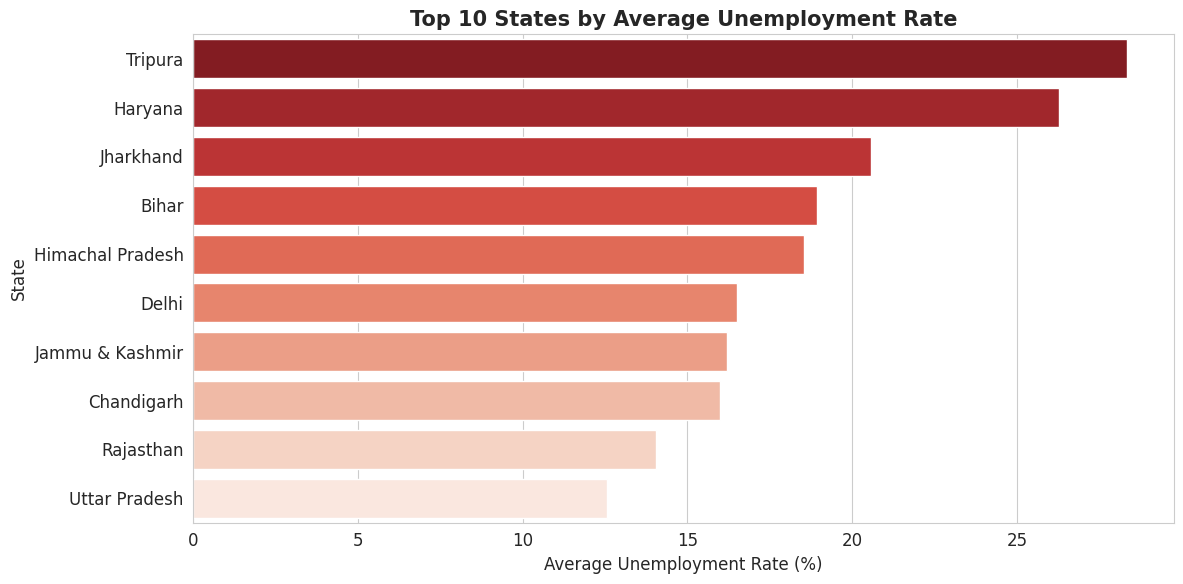

Chart 1 saved!


In [18]:
# Chart 1: Top 10 States by Average Unemployment Rate

state_avg = unemp.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=state_avg.values, y=state_avg.index, palette='Reds_r')
plt.title('Top 10 States by Average Unemployment Rate', fontsize=15, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart1_top10_states_unemployment.png', dpi=150)
plt.show()
print("Chart 1 saved!")

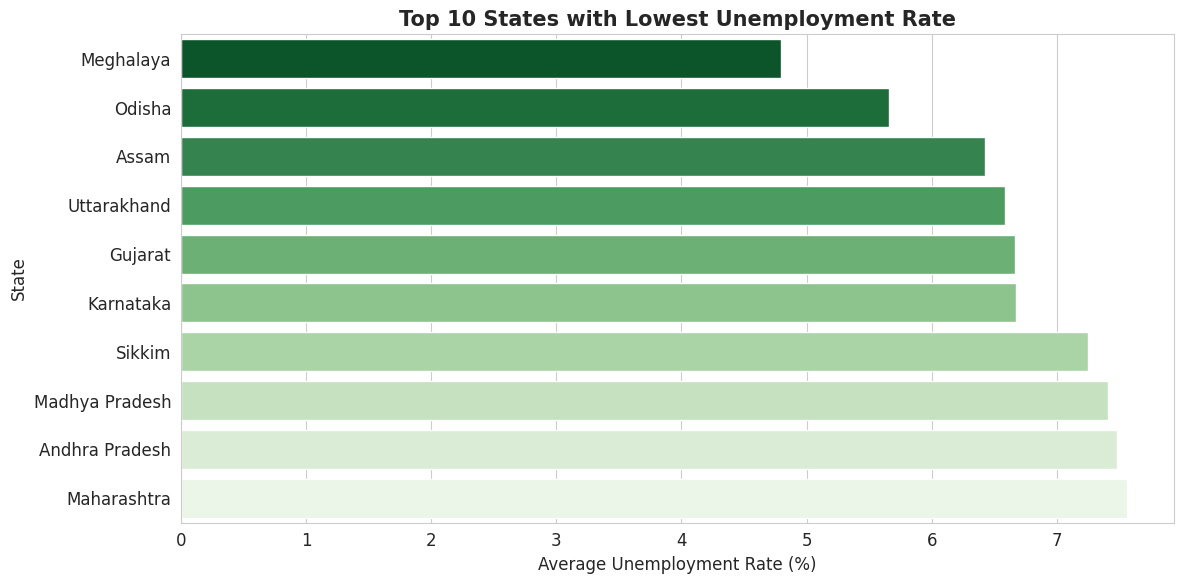

Chart 2 saved!


In [19]:
#  Chart 2: Bottom 10 States (Lowest Unemployment)

state_low = unemp.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=True).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=state_low.values, y=state_low.index, palette='Greens_r')
plt.title('Top 10 States with Lowest Unemployment Rate', fontsize=15, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart2_lowest_unemployment_states.png', dpi=150)
plt.show()
print("Chart 2 saved!")

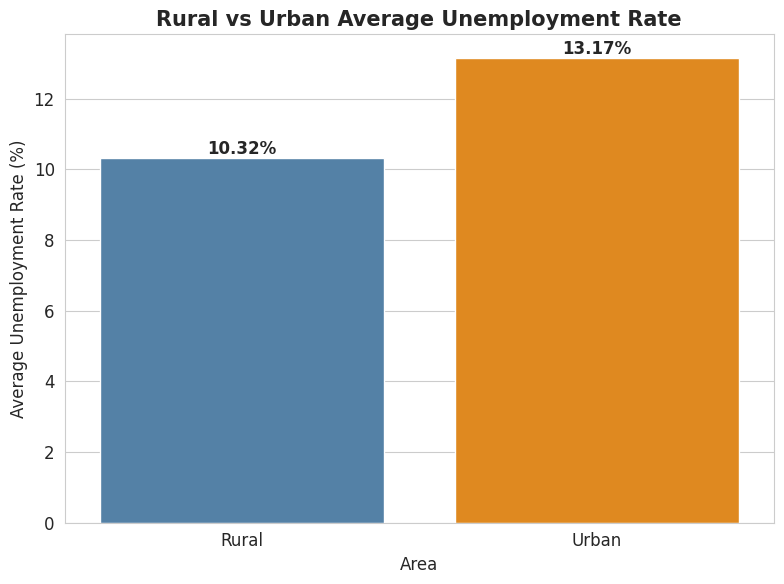

Chart 3 saved!


In [20]:
# Chart 3: Rural vs Urban Unemployment Comparison

rural_urban = unemp.groupby(['Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='Area', y='Unemployment_Rate', data=rural_urban,
            palette=['steelblue', 'darkorange'])
plt.title('Rural vs Urban Average Unemployment Rate', fontsize=15, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
for i, v in enumerate(rural_urban['Unemployment_Rate']):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_path}/chart3_rural_vs_urban.png', dpi=150)
plt.show()
print("Chart 3 saved!")

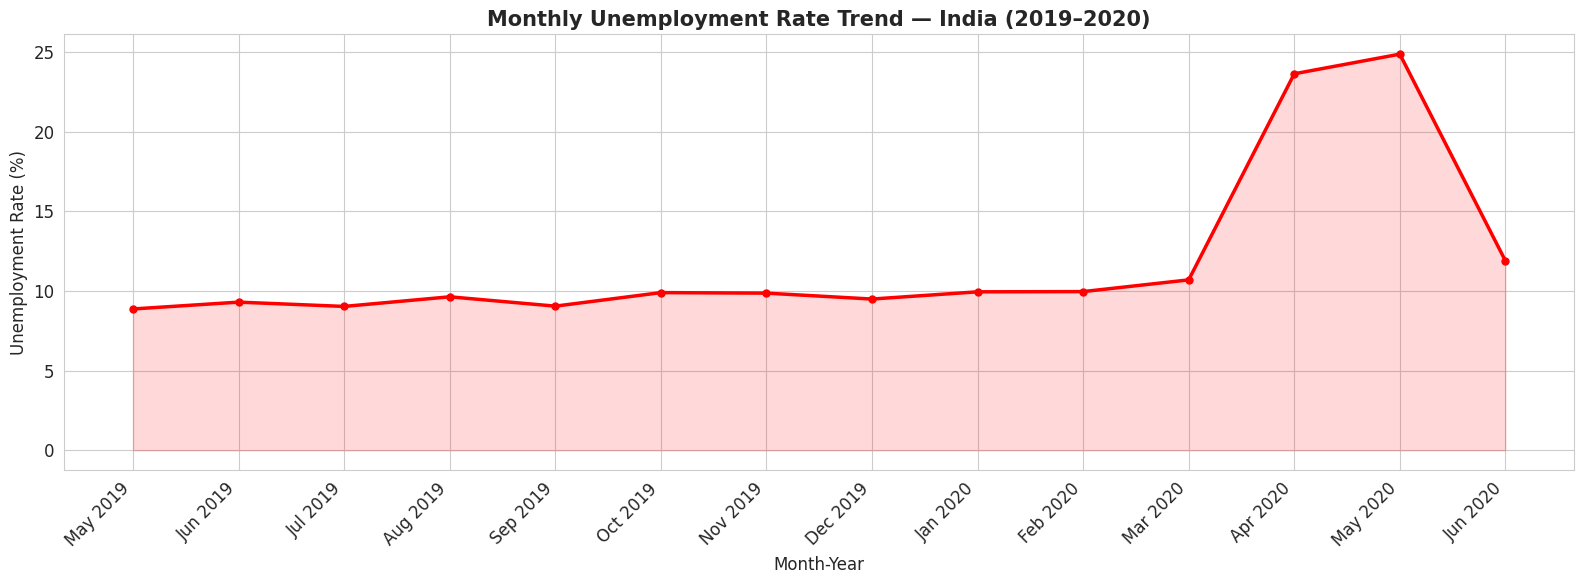

Chart 4 saved!


In [21]:
# Chart 4: Monthly Unemployment Trend

monthly = unemp.groupby(['Year', 'Month', 'Month_Name'])['Unemployment_Rate'].mean().reset_index()
monthly = monthly.sort_values(['Year', 'Month'])
monthly['Period'] = monthly['Month_Name'] + ' ' + monthly['Year'].astype(str)

plt.figure(figsize=(16,6))
plt.plot(monthly['Period'], monthly['Unemployment_Rate'],
         color='red', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(range(len(monthly)), monthly['Unemployment_Rate'],
                 alpha=0.15, color='red')
plt.title('Monthly Unemployment Rate Trend — India (2019–2020)', fontsize=15, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(range(len(monthly)), monthly['Period'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_path}/chart4_monthly_trend.png', dpi=150)
plt.show()
print("Chart 4 saved!")

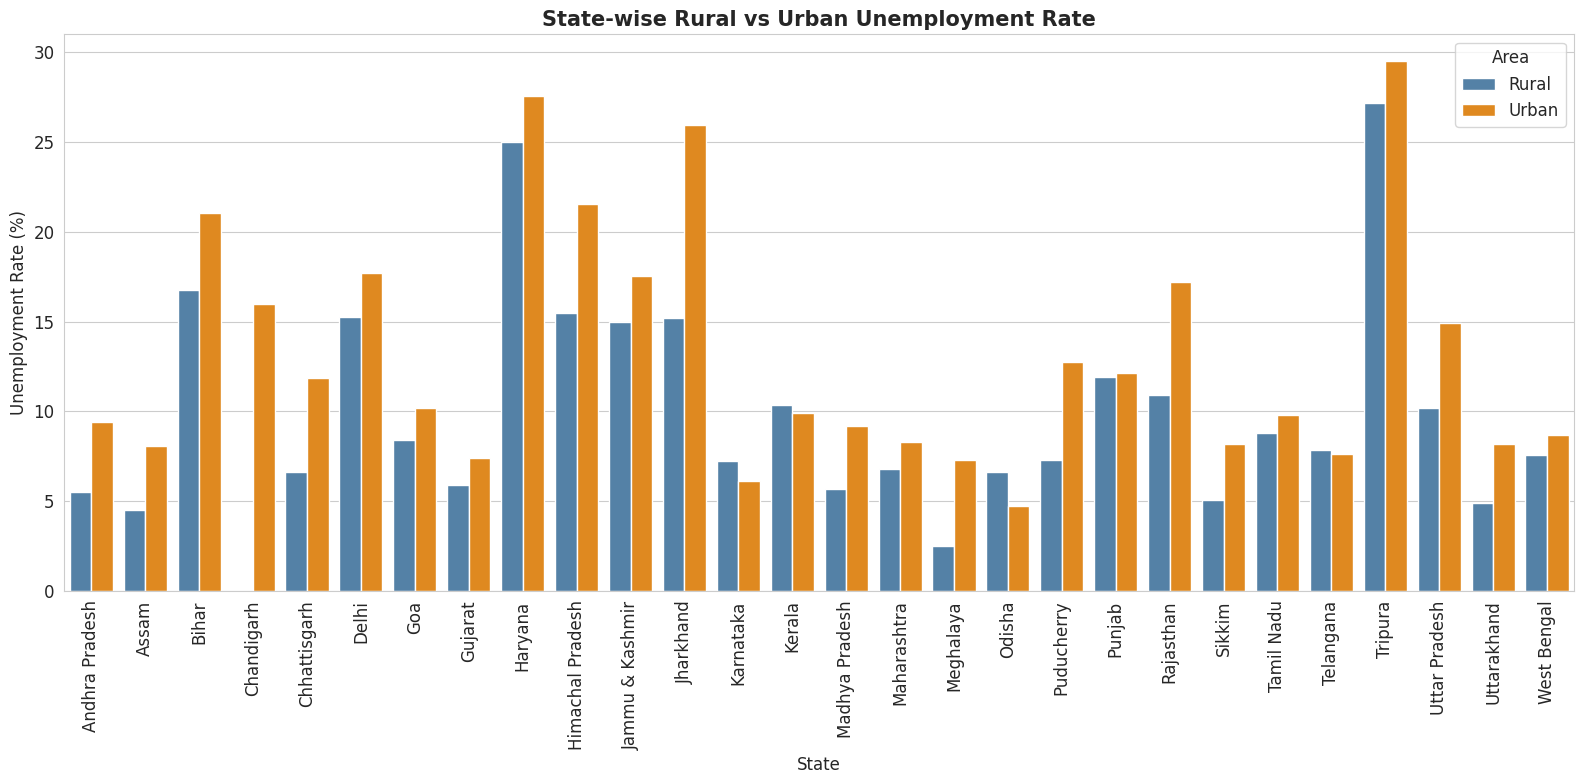

Chart 5 saved!


In [22]:
# Chart 5: State wise Rural vs Urban Side by Side

state_area = unemp.groupby(['State', 'Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(16,8))
sns.barplot(data=state_area, x='State', y='Unemployment_Rate',
            hue='Area', palette=['steelblue', 'darkorange'])
plt.title('State-wise Rural vs Urban Unemployment Rate', fontsize=15, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.legend(title='Area')
plt.tight_layout()
plt.savefig(f'{output_path}/chart5_statewise_rural_urban.png', dpi=150)
plt.show()
print("Chart 5 saved!")

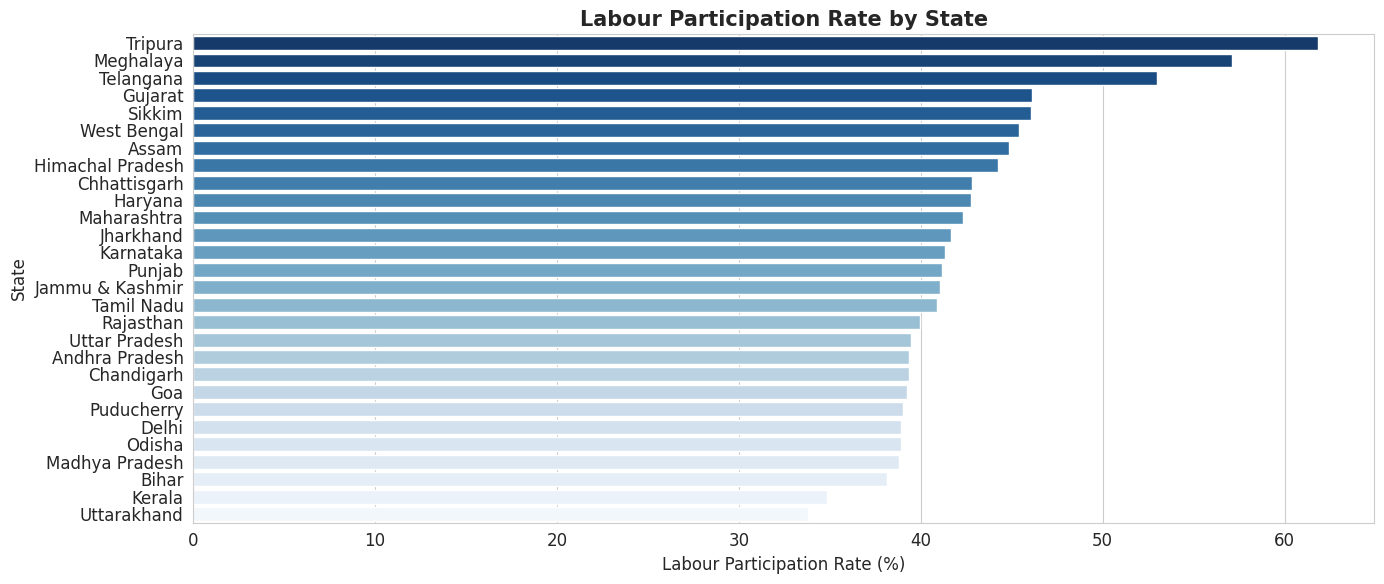

Chart 6 saved!


In [23]:
# Chart 6: Labour Participation Rate by State

lpr = unemp.groupby('State')['Labour_Participation_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=lpr.values, y=lpr.index, palette='Blues_r')
plt.title('Labour Participation Rate by State', fontsize=15, fontweight='bold')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart6_labour_participation.png', dpi=150)
plt.show()
print("Chart 6 saved!")

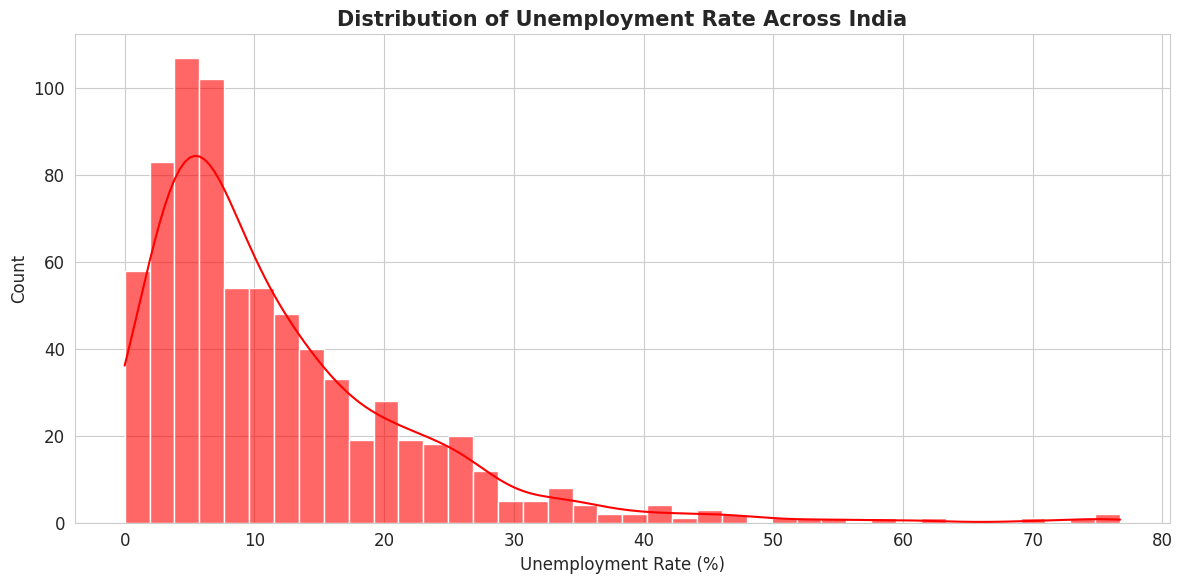

Chart 7 saved!


In [24]:
# Chart 7: Unemployment Rate Distribution

plt.figure(figsize=(12,6))
sns.histplot(unemp['Unemployment_Rate'], bins=40, kde=True,
             color='red', alpha=0.6)
plt.title('Distribution of Unemployment Rate Across India', fontsize=15, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{output_path}/chart7_unemployment_distribution.png', dpi=150)
plt.show()
print("Chart 7 saved!")

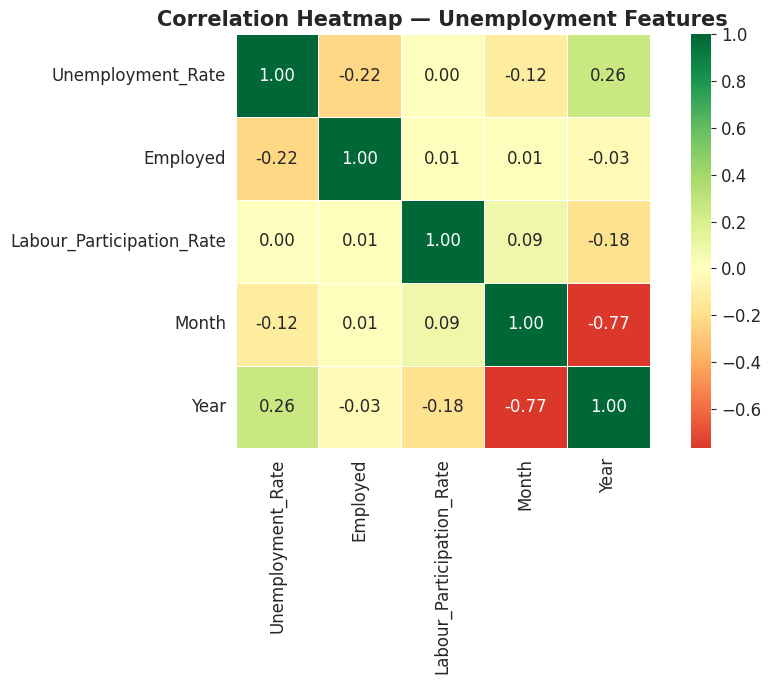

Chart 8 saved!


In [25]:
# Chart 8: Correlation Heatmap

corr_cols = ['Unemployment_Rate', 'Employed',
             'Labour_Participation_Rate', 'Month', 'Year']

corr = unemp[corr_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Unemployment Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_path}/chart8_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 8 saved!")

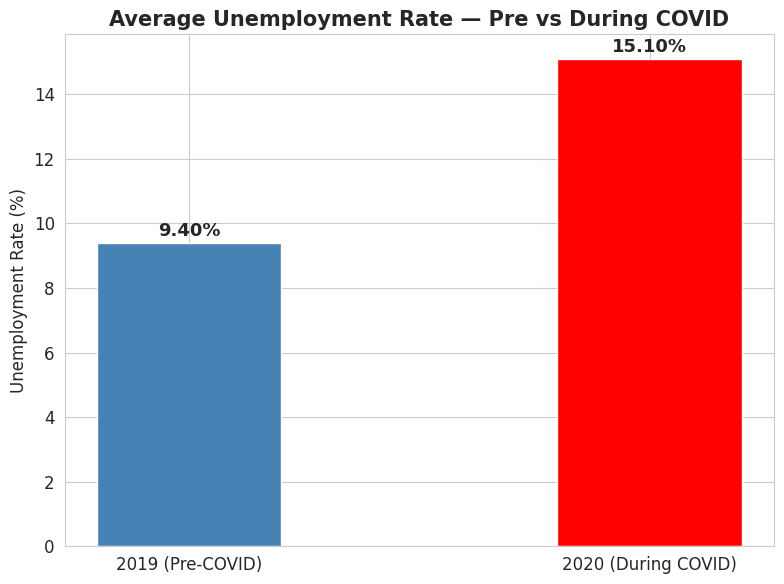

Chart 9 saved!


In [26]:
# Chart 9: COVID Impact (Pre vs During)

pre_covid = unemp[unemp['Year'] == 2019]['Unemployment_Rate'].mean()
during_covid = unemp[unemp['Year'] == 2020]['Unemployment_Rate'].mean()

plt.figure(figsize=(8,6))
bars = plt.bar(['2019 (Pre-COVID)', '2020 (During COVID)'],
               [pre_covid, during_covid],
               color=['steelblue', 'red'], width=0.4)
plt.title('Average Unemployment Rate — Pre vs During COVID', fontsize=15, fontweight='bold')
plt.ylabel('Unemployment Rate (%)')
for bar, val in zip(bars, [pre_covid, during_covid]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_path}/chart9_covid_impact.png', dpi=150)
plt.show()
print("Chart 9 saved!")

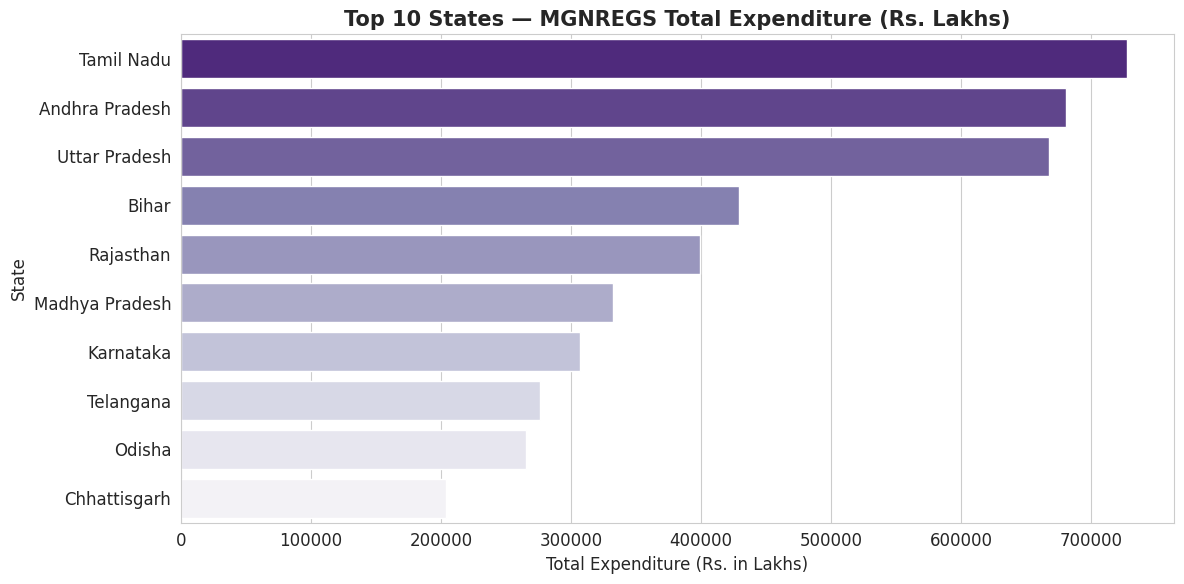

Chart 10 saved!


In [27]:
# Chart 10: MGNREGS — Top 10 States by Total Expenditure

top_exp = mgnregs_state.sort_values('Total_Expenditure_Lakhs', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='Total_Expenditure_Lakhs', y='State',
            data=top_exp, palette='Purples_r')
plt.title('Top 10 States — MGNREGS Total Expenditure (Rs. Lakhs)', fontsize=15, fontweight='bold')
plt.xlabel('Total Expenditure (Rs. in Lakhs)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart10_mgnregs_expenditure.png', dpi=150)
plt.show()
print("Chart 10 saved!")

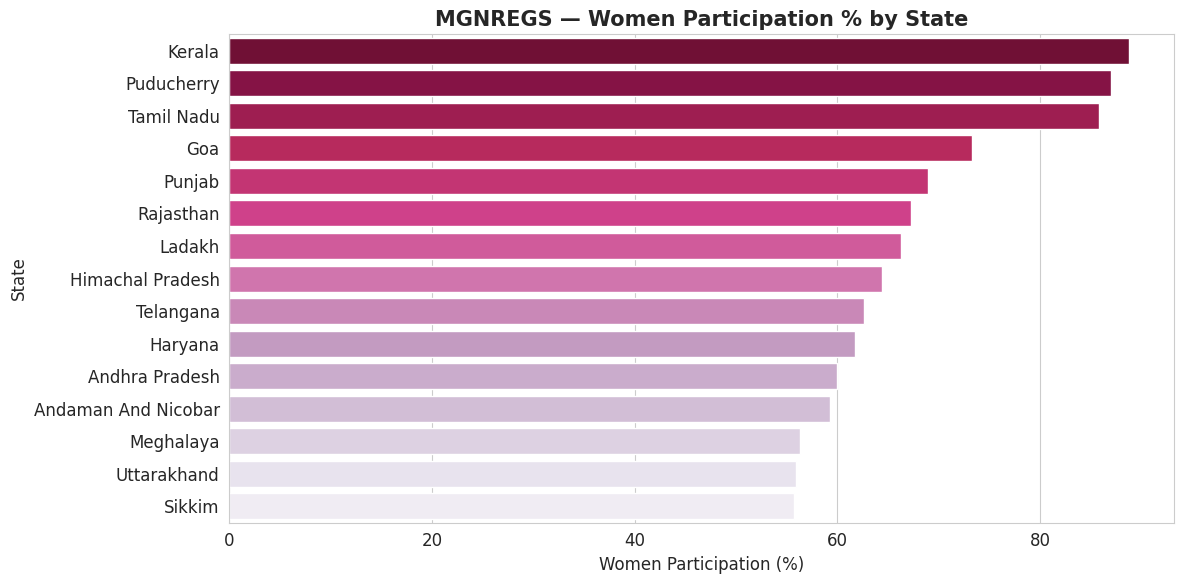

Chart 11 saved!


In [28]:
# Chart 11: MGNREGS — Women Participation by State

women = mgnregs_state.sort_values('Women_Participation_Pct', ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(x='Women_Participation_Pct', y='State',
            data=women, palette='PuRd_r')
plt.title('MGNREGS — Women Participation % by State', fontsize=15, fontweight='bold')
plt.xlabel('Women Participation (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart11_women_participation.png', dpi=150)
plt.show()
print("Chart 11 saved!")

In [29]:
# Chart 12: MGNREGS — Average Wage Per Day by State

wage = mgnregs_state.sort_values('Avg_Wage_Per_Day', ascending=False)

plt.figure(figsize=(14,7))
sns.barplot(x='Avg_Wage_Per_Day', y='State',
            data=wage, palette='YlOrRd_r')
plt.title('MGNREGS — Average Wage Per Day by State (Rs.)', fontsize=15, fontweight='bold')
plt.xlabel('Average Wage Per Day (Rs.)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart12_avg_wage.png', dpi=150)
plt.show()
print("Chart 12 saved!")

In [ ]:
# Chart 13: Scheme Reach % by State

reach = mgnregs_state.sort_values('Scheme_Reach_Pct', ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(x='Scheme_Reach_Pct', y='State',
            data=reach, palette='Greens_r')
plt.title('MGNREGS — Scheme Reach % by State', fontsize=15, fontweight='bold')
plt.xlabel('Scheme Reach (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(f'{output_path}/chart13_scheme_reach.png', dpi=150)
plt.show()
print("Chart 13 saved!")

In [ ]:
#  Chart 14: Global Unemployment — India Trend

plt.figure(figsize=(12,6))
plt.plot(india_global['Year'], india_global['Global_Unemployment_Rate'],
         color='darkblue', linewidth=2.5, marker='o', markersize=6)
plt.fill_between(india_global['Year'],
                 india_global['Global_Unemployment_Rate'],
                 alpha=0.15, color='darkblue')
plt.title('India Unemployment Rate — Global Dataset (1991–2021)', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(india_global['Year'][::2], rotation=45)
plt.tight_layout()
plt.savefig(f'{output_path}/chart14_india_global_trend.png', dpi=150)
plt.show()
print("Chart 14 saved!")

In [ ]:
# Confirm All Charts Saved

import os
charts = sorted(os.listdir(output_path))
print(f"Total files saved: {len(charts)}")
print("\nAll saved files:")
for c in charts:
    print(f"  ✅ {c}")

Phase 4 — ML Models

In [32]:
#  Prepare ML Dataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create unemployment risk category — target variable
def categorize_unemployment(rate):
    if rate >= 15:
        return 'High'
    elif rate >= 7:
        return 'Medium'
    else:
        return 'Low'

unemp['Risk_Category'] = unemp['Unemployment_Rate'].apply(categorize_unemployment)

print("Risk Category Distribution:")
print(unemp['Risk_Category'].value_counts())
print("\nSample:")
print(unemp[['State', 'Unemployment_Rate', 'Risk_Category']].head(10))

Risk Category Distribution:
Risk_Category
Low       315
Medium    226
High      199
Name: count, dtype: int64

Sample:
            State  Unemployment_Rate Risk_Category
0  Andhra Pradesh               3.65           Low
1  Andhra Pradesh               3.05           Low
2  Andhra Pradesh               3.75           Low
3  Andhra Pradesh               3.32           Low
4  Andhra Pradesh               5.17           Low
5  Andhra Pradesh               3.52           Low
6  Andhra Pradesh               4.12           Low
7  Andhra Pradesh               4.38           Low
8  Andhra Pradesh               4.84           Low
9  Andhra Pradesh               5.91           Low


In [33]:
# Encode Features for ML

# Label encode categorical columns
le_state = LabelEncoder()
le_area = LabelEncoder()
le_risk = LabelEncoder()

unemp['State_Encoded'] = le_state.fit_transform(unemp['State'])
unemp['Area_Encoded'] = le_area.fit_transform(unemp['Area'])
unemp['Risk_Encoded'] = le_risk.fit_transform(unemp['Risk_Category'])

# Define features and target
features = ['State_Encoded', 'Area_Encoded', 'Employed',
            'Labour_Participation_Rate', 'Month', 'Year']

target = 'Risk_Encoded'

X = unemp[features]
y = unemp[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Feature matrix shape:", X.shape)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTarget classes:", le_risk.classes_)

Feature matrix shape: (740, 6)
Training set: (592, 6)
Testing set: (148, 6)

Target classes: ['High' 'Low' 'Medium']


In [34]:
# Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {acc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=le_risk.classes_))

=== LOGISTIC REGRESSION ===
Accuracy: 0.4257

Classification Report:
              precision    recall  f1-score   support

        High       0.28      0.33      0.30        40
         Low       0.48      0.68      0.57        63
      Medium       0.54      0.16      0.24        45

    accuracy                           0.43       148
   macro avg       0.43      0.39      0.37       148
weighted avg       0.45      0.43      0.40       148



In [35]:
# Model 2: Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== RANDOM FOREST CLASSIFIER ===")
print(f"Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=le_risk.classes_))

=== RANDOM FOREST CLASSIFIER ===
Accuracy: 0.7297

Classification Report:
              precision    recall  f1-score   support

        High       0.70      0.75      0.72        40
         Low       0.84      0.76      0.80        63
      Medium       0.62      0.67      0.65        45

    accuracy                           0.73       148
   macro avg       0.72      0.73      0.72       148
weighted avg       0.74      0.73      0.73       148



In [36]:
# Model 3: XGBoost Classifier

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("=== XGBOOST CLASSIFIER ===")
print(f"Accuracy: {acc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=le_risk.classes_))

=== XGBOOST CLASSIFIER ===
Accuracy: 0.6689

Classification Report:
              precision    recall  f1-score   support

        High       0.63      0.65      0.64        40
         Low       0.81      0.75      0.78        63
      Medium       0.53      0.58      0.55        45

    accuracy                           0.67       148
   macro avg       0.66      0.66      0.66       148
weighted avg       0.68      0.67      0.67       148



In [37]:
# Model Comparison Table

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [round(acc_lr,4), round(acc_rf,4), round(acc_xgb,4)]
})

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

best_model = results.loc[results['Accuracy'].idxmax(), 'Model']
best_acc = results['Accuracy'].max()
print(f"\n✅ Best Model: {best_model} with Accuracy: {best_acc:.4f}")

=== MODEL COMPARISON ===
              Model  Accuracy
Logistic Regression    0.4257
      Random Forest    0.7297
            XGBoost    0.6689

✅ Best Model: Random Forest with Accuracy: 0.7297


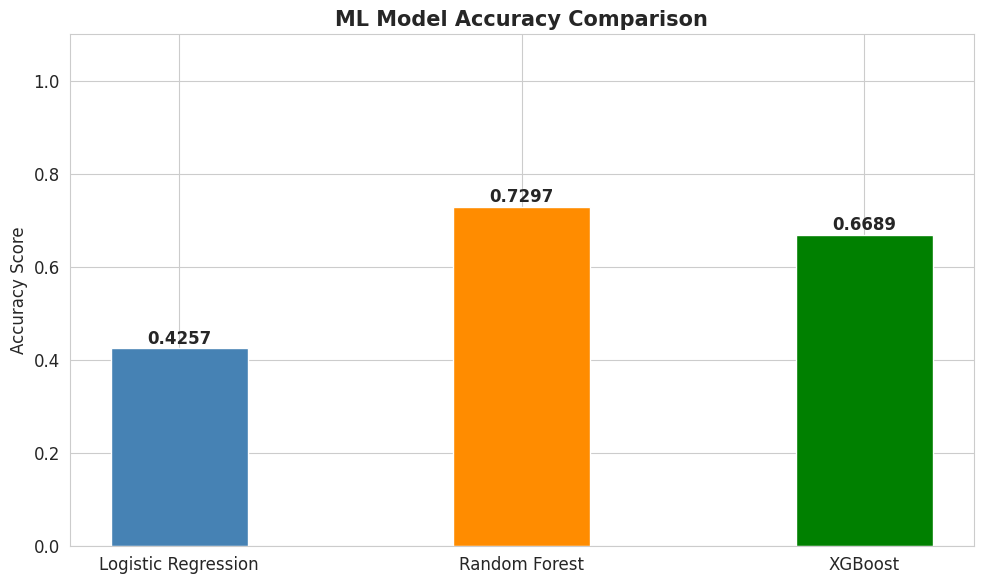

Chart 15 saved!


In [38]:
# Chart 15: Model Accuracy Comparison

plt.figure(figsize=(10,6))
bars = plt.bar(results['Model'], results['Accuracy'],
               color=['steelblue', 'darkorange', 'green'],
               width=0.4)
plt.title('ML Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.1)
for bar, val in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_path}/chart15_model_accuracy.png', dpi=150)
plt.show()
print("Chart 15 saved!")

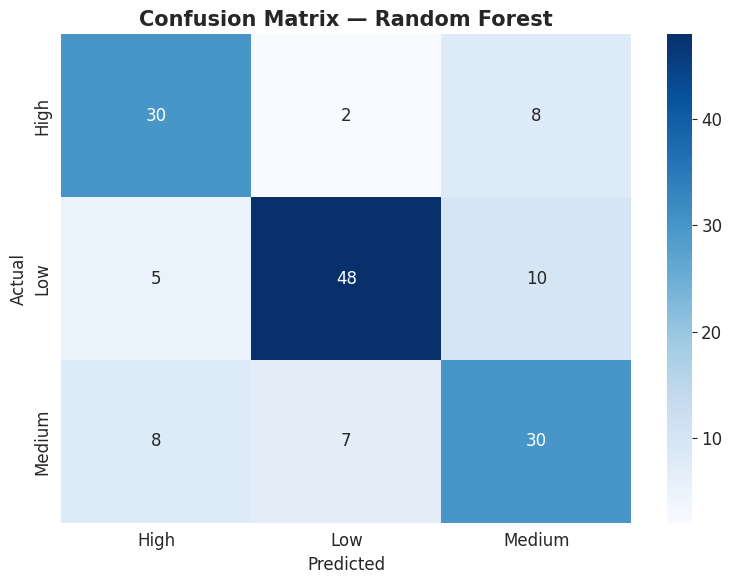

Chart 16 saved!


In [39]:
#  Chart 16: Confusion Matrix (Best Model)

# Use best model predictions
if best_model == 'XGBoost':
    y_best = y_pred_xgb
elif best_model == 'Random Forest':
    y_best = y_pred_rf
else:
    y_best = y_pred_lr

cm = confusion_matrix(y_test, y_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)
plt.title(f'Confusion Matrix — {best_model}', fontsize=15, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{output_path}/chart16_confusion_matrix.png', dpi=150)
plt.show()
print("Chart 16 saved!")

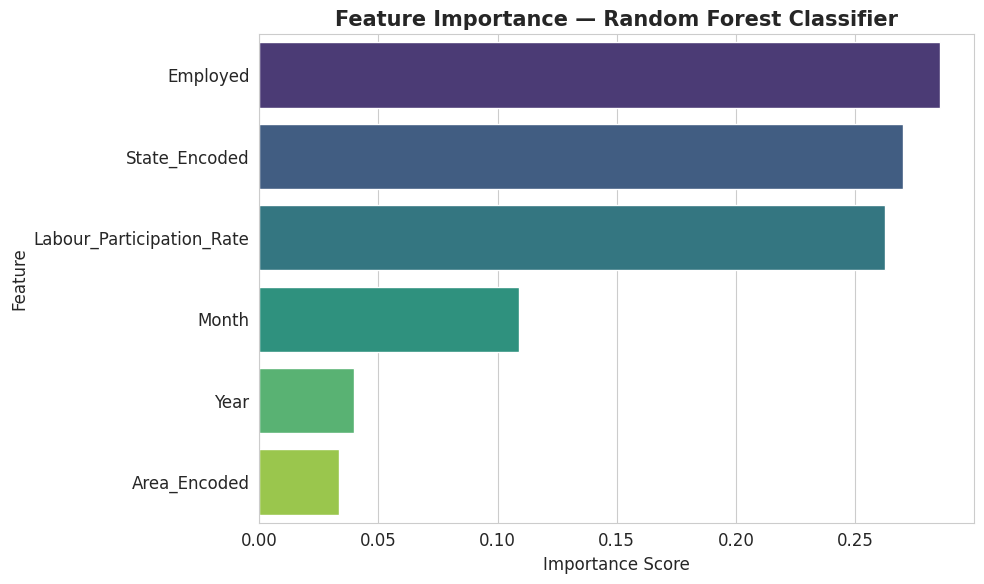

Chart 17 saved!


In [40]:
# Chart 17: Feature Importance (Random Forest)

importances = pd.Series(rf.feature_importances_,
                        index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance — Random Forest Classifier', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{output_path}/chart17_feature_importance.png', dpi=150)
plt.show()
print("Chart 17 saved!")

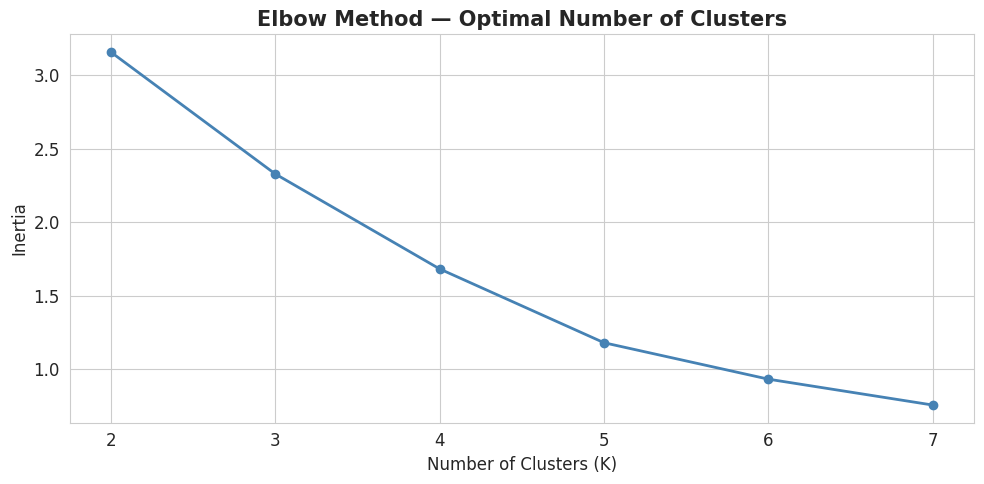

Chart 18 saved!


In [41]:
# Clustering: K-Means on States

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# State level aggregation for clustering
state_cluster_data = unemp.groupby('State').agg(
    Avg_Unemployment=('Unemployment_Rate', 'mean'),
    Avg_Labour_Participation=('Labour_Participation_Rate', 'mean'),
    Avg_Employed=('Employed', 'mean')
).reset_index()

# Normalize
scaler = MinMaxScaler()
X_cluster = scaler.fit_transform(
    state_cluster_data[['Avg_Unemployment',
                         'Avg_Labour_Participation',
                         'Avg_Employed']]
)

# Find optimal K using elbow method
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(f'{output_path}/chart18_elbow_method.png', dpi=150)
plt.show()
print("Chart 18 saved!")

In [42]:
# Apply K-Means Clustering

# Apply K=3 clusters
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
state_cluster_data['Cluster'] = km_final.fit_predict(X_cluster)

# Name clusters based on unemployment level
cluster_means = state_cluster_data.groupby('Cluster')['Avg_Unemployment'].mean()
cluster_rank = cluster_means.rank().astype(int)

cluster_names = {}
for cluster, rank in cluster_rank.items():
    if rank == 1:
        cluster_names[cluster] = 'Low Unemployment'
    elif rank == 2:
        cluster_names[cluster] = 'Medium Unemployment'
    else:
        cluster_names[cluster] = 'High Unemployment'

state_cluster_data['Cluster_Name'] = state_cluster_data['Cluster'].map(cluster_names)

print("=== STATE CLUSTERS ===")
print(state_cluster_data[['State', 'Avg_Unemployment',
                            'Avg_Labour_Participation',
                            'Cluster_Name']].sort_values(
                            'Avg_Unemployment',
                            ascending=False).to_string(index=False))

=== STATE CLUSTERS ===
           State  Avg_Unemployment  Avg_Labour_Participation        Cluster_Name
         Tripura         28.350357                 61.823929   High Unemployment
         Haryana         26.283214                 42.737143   High Unemployment
       Jharkhand         20.585000                 41.670714   High Unemployment
           Bihar         18.918214                 38.153929   High Unemployment
Himachal Pradesh         18.540357                 44.222143   High Unemployment
           Delhi         16.495357                 38.929643   High Unemployment
 Jammu & Kashmir         16.188571                 41.030952   High Unemployment
      Chandigarh         15.991667                 39.336667   High Unemployment
       Rajasthan         14.058214                 39.973214    Low Unemployment
   Uttar Pradesh         12.551429                 39.432500 Medium Unemployment
          Punjab         12.031071                 41.138214    Low Unemployment
     

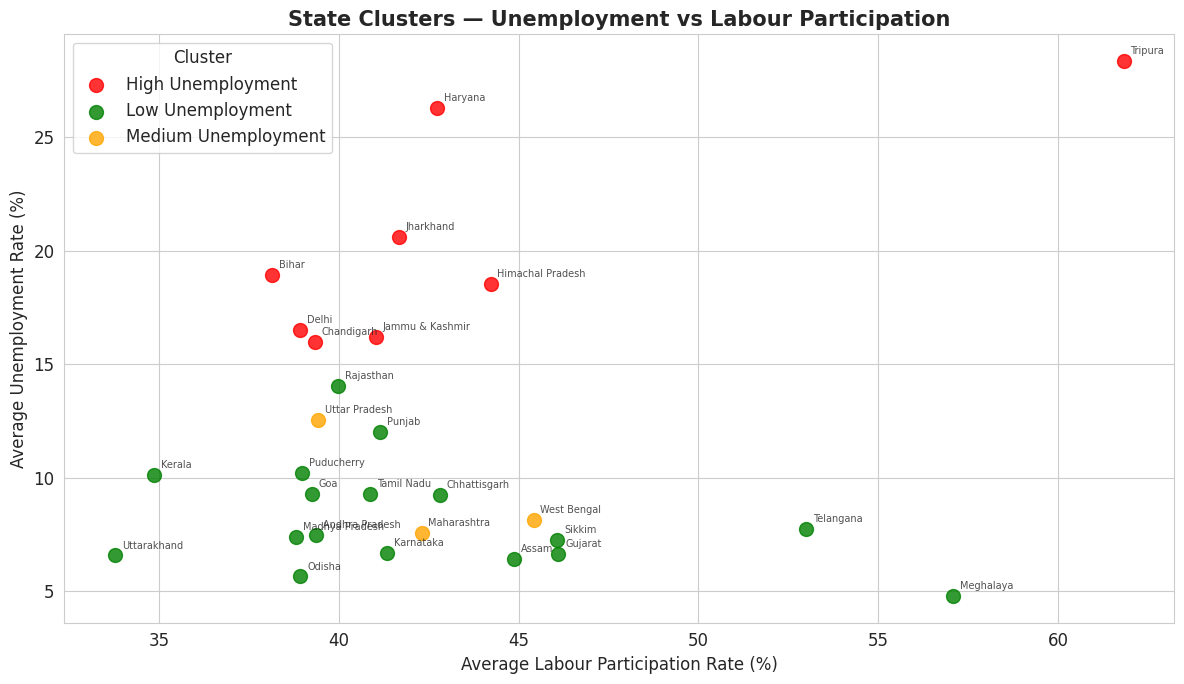

Chart 19 saved!


In [43]:
# Chart 19: State Clusters Scatter Plot

colors = {'Low Unemployment': 'green',
          'Medium Unemployment': 'orange',
          'High Unemployment': 'red'}

plt.figure(figsize=(12,7))
for cluster_name, group in state_cluster_data.groupby('Cluster_Name'):
    plt.scatter(group['Avg_Labour_Participation'],
                group['Avg_Unemployment'],
                label=cluster_name,
                color=colors[cluster_name],
                s=100, alpha=0.8)
    for _, row in group.iterrows():
        plt.annotate(row['State'],
                    (row['Avg_Labour_Participation'],
                     row['Avg_Unemployment']),
                    fontsize=7, alpha=0.8,
                    xytext=(5,5), textcoords='offset points')

plt.title('State Clusters — Unemployment vs Labour Participation',
          fontsize=15, fontweight='bold')
plt.xlabel('Average Labour Participation Rate (%)')
plt.ylabel('Average Unemployment Rate (%)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig(f'{output_path}/chart19_state_clusters.png', dpi=150)
plt.show()
print("Chart 19 saved!")

States matched for analysis: 25


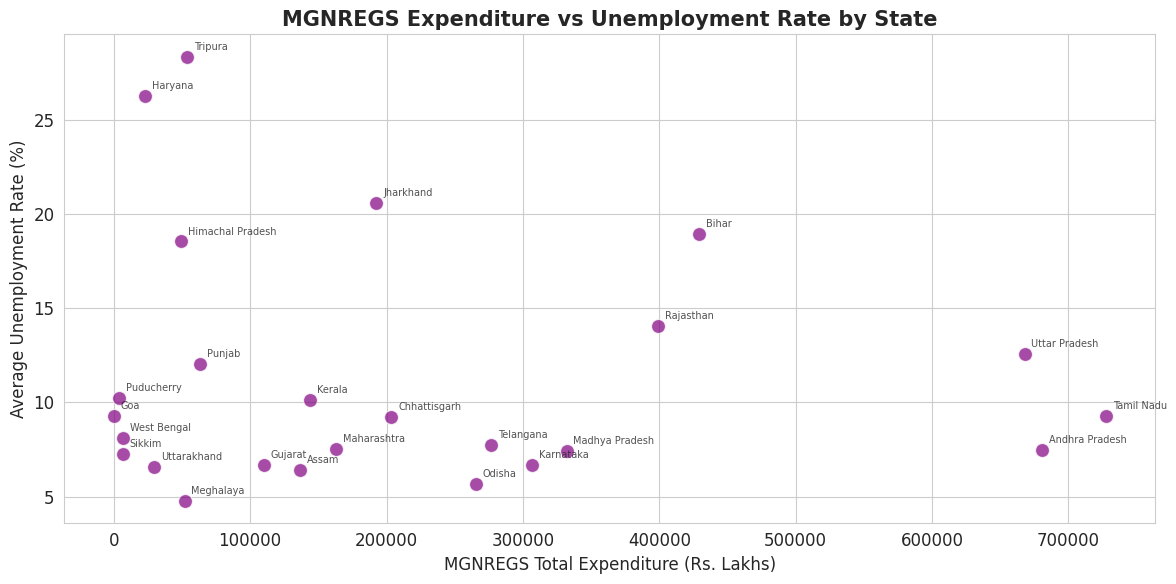

Chart 20 saved!


In [44]:
# Chart 20: MGNREGS vs Unemployment Correlation

# Merge unemployment state avg with mgnregs state data
unemp_state_avg = unemp.groupby('State')['Unemployment_Rate'].mean().reset_index()
unemp_state_avg.columns = ['State', 'Avg_Unemployment']

# Standardise state names for merge
mgnregs_state['State'] = mgnregs_state['State'].str.strip().str.title()
unemp_state_avg['State'] = unemp_state_avg['State'].str.strip().str.title()

merged_analysis = pd.merge(unemp_state_avg, mgnregs_state, on='State', how='inner')

print(f"States matched for analysis: {merged_analysis.shape[0]}")

plt.figure(figsize=(12,6))
sns.scatterplot(data=merged_analysis,
                x='Total_Expenditure_Lakhs',
                y='Avg_Unemployment',
                s=100, color='purple', alpha=0.7)

for _, row in merged_analysis.iterrows():
    plt.annotate(row['State'],
                (row['Total_Expenditure_Lakhs'],
                 row['Avg_Unemployment']),
                fontsize=7, alpha=0.8,
                xytext=(5,5), textcoords='offset points')

plt.title('MGNREGS Expenditure vs Unemployment Rate by State',
          fontsize=15, fontweight='bold')
plt.xlabel('MGNREGS Total Expenditure (Rs. Lakhs)')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.savefig(f'{output_path}/chart20_mgnregs_vs_unemployment.png', dpi=150)
plt.show()
print("Chart 20 saved!")

In [45]:
# Save All Models and Results

import joblib

joblib.dump(lr, f'{output_path}/model_logistic_regression.pkl')
joblib.dump(rf, f'{output_path}/model_random_forest.pkl')
joblib.dump(xgb, f'{output_path}/model_xgboost.pkl')

results.to_csv(f'{output_path}/model_comparison_results.csv', index=False)
state_cluster_data.to_csv(f'{output_path}/state_clusters.csv', index=False)
merged_analysis.to_csv(f'{output_path}/mgnregs_unemployment_merged.csv', index=False)

print("All models and results saved!")

All models and results saved!


In [46]:
# Final File Check

import os
all_files = sorted(os.listdir(output_path))
print(f"Total files in outputs: {len(all_files)}")
print("\nAll files:")
for f in all_files:
    print(f"  ✅ {f}")

Total files in outputs: 26

All files:
  ✅ chart10_mgnregs_expenditure.png
  ✅ chart11_women_participation.png
  ✅ chart12_avg_wage.png
  ✅ chart13_scheme_reach.png
  ✅ chart14_india_global_trend.png
  ✅ chart15_model_accuracy.png
  ✅ chart16_confusion_matrix.png
  ✅ chart17_feature_importance.png
  ✅ chart18_elbow_method.png
  ✅ chart19_state_clusters.png
  ✅ chart1_top10_states_unemployment.png
  ✅ chart20_mgnregs_vs_unemployment.png
  ✅ chart2_lowest_unemployment_states.png
  ✅ chart3_rural_vs_urban.png
  ✅ chart4_monthly_trend.png
  ✅ chart5_statewise_rural_urban.png
  ✅ chart6_labour_participation.png
  ✅ chart7_unemployment_distribution.png
  ✅ chart8_correlation_heatmap.png
  ✅ chart9_covid_impact.png
  ✅ mgnregs_unemployment_merged.csv
  ✅ model_comparison_results.csv
  ✅ model_logistic_regression.pkl
  ✅ model_random_forest.pkl
  ✅ model_xgboost.pkl
  ✅ state_clusters.csv


Phase 5 — NLP Analysis + Final Summary

In [47]:
# Install and Import NLP Libraries

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
import re

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("NLP libraries ready!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLP libraries ready!


In [48]:
# Scheme Descriptions

schemes = {
    'MGNREGS': """
        provides legal guarantee hundred days wage employment financial year
        adult members rural households demand employment willing unskilled
        manual work targets rural poor households women scheduled castes
        scheduled tribes employment provided within five kilometers applicant
        residence wages paid according minimum wage rates creation durable
        assets roads water conservation structures irrigation canals land
        development works rural areas women participation encouraged one third
        reservation women workers strengthen livelihood resource base rural poor
    """,
    'PMKVY': """
        flagship scheme skill india mission operated ministry skill development
        entrepreneurship aims enable large number indian youth take industry
        relevant skill training help securing better livelihood candidates prior
        learning experience skills assessed certified recognition prior learning
        training assessment fees completely paid government focus sectors
        construction electronics hardware food processing furniture fittings
        handicrafts gems jewellery leather technology targets unemployed youth
        school college dropouts provide industry recognized certifications
        improve employment prospects earnings
    """,
    'PM_SVANidhi': """
        provides affordable collateral free working capital loans street vendors
        livelihoods adversely affected covid pandemic lockdowns vendors avail
        working capital loan ten thousand rupees repayable monthly instalments
        tenure one year timely repayment loan vendors eligible enhanced credit
        limit subsequent loan cycle digital transactions incentivized cashback
        facility targets street vendors operating urban areas surrounding peri
        urban rural areas sell vegetables fruits ready eat street food tea
        pakodas books stationary garments footwear artisan products
    """,
    'PMEGP': """
        credit linked subsidy programme aimed generating self employment
        opportunities establishment micro enterprises non farm sector helping
        traditional artisans unemployed youth implemented khadi village
        industries commission national level maximum project cost manufacturing
        sector twenty five lakh rupees service sector ten lakh rupees
        beneficiaries belonging special categories scheduled castes scheduled
        tribes women ex servicemen physically handicapped minorities hill border
        areas get higher subsidy rates aims provide sustainable employment
        rural urban unemployed youth traditional artisans
    """
}

print("Schemes loaded:", list(schemes.keys()))

Schemes loaded: ['MGNREGS', 'PMKVY', 'PM_SVANidhi', 'PMEGP']


In [50]:
#  Clean and Tokenize Scheme Text

stop_words = set(stopwords.words('english'))

custom_stops = {'scheme', 'the', 'and', 'for', 'of', 'in',
                'to', 'a', 'is', 'are', 'will', 'be', 'their',
                'with', 'under', 'at', 'on', 'by', 'from',
                'up', 'who', 'an', 'as', 'or', 'which', 'per',
                'also', 'that', 'this', 'all', 'through'}

stop_words.update(custom_stops)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 3]
    return tokens

scheme_tokens = {}
for scheme_name, text in schemes.items():
    tokens = clean_text(text)
    scheme_tokens[scheme_name] = tokens
    print(f"{scheme_name}: {len(tokens)} meaningful words")


MGNREGS: 68 meaningful words
PMKVY: 68 meaningful words
PM_SVANidhi: 67 meaningful words
PMEGP: 68 meaningful words


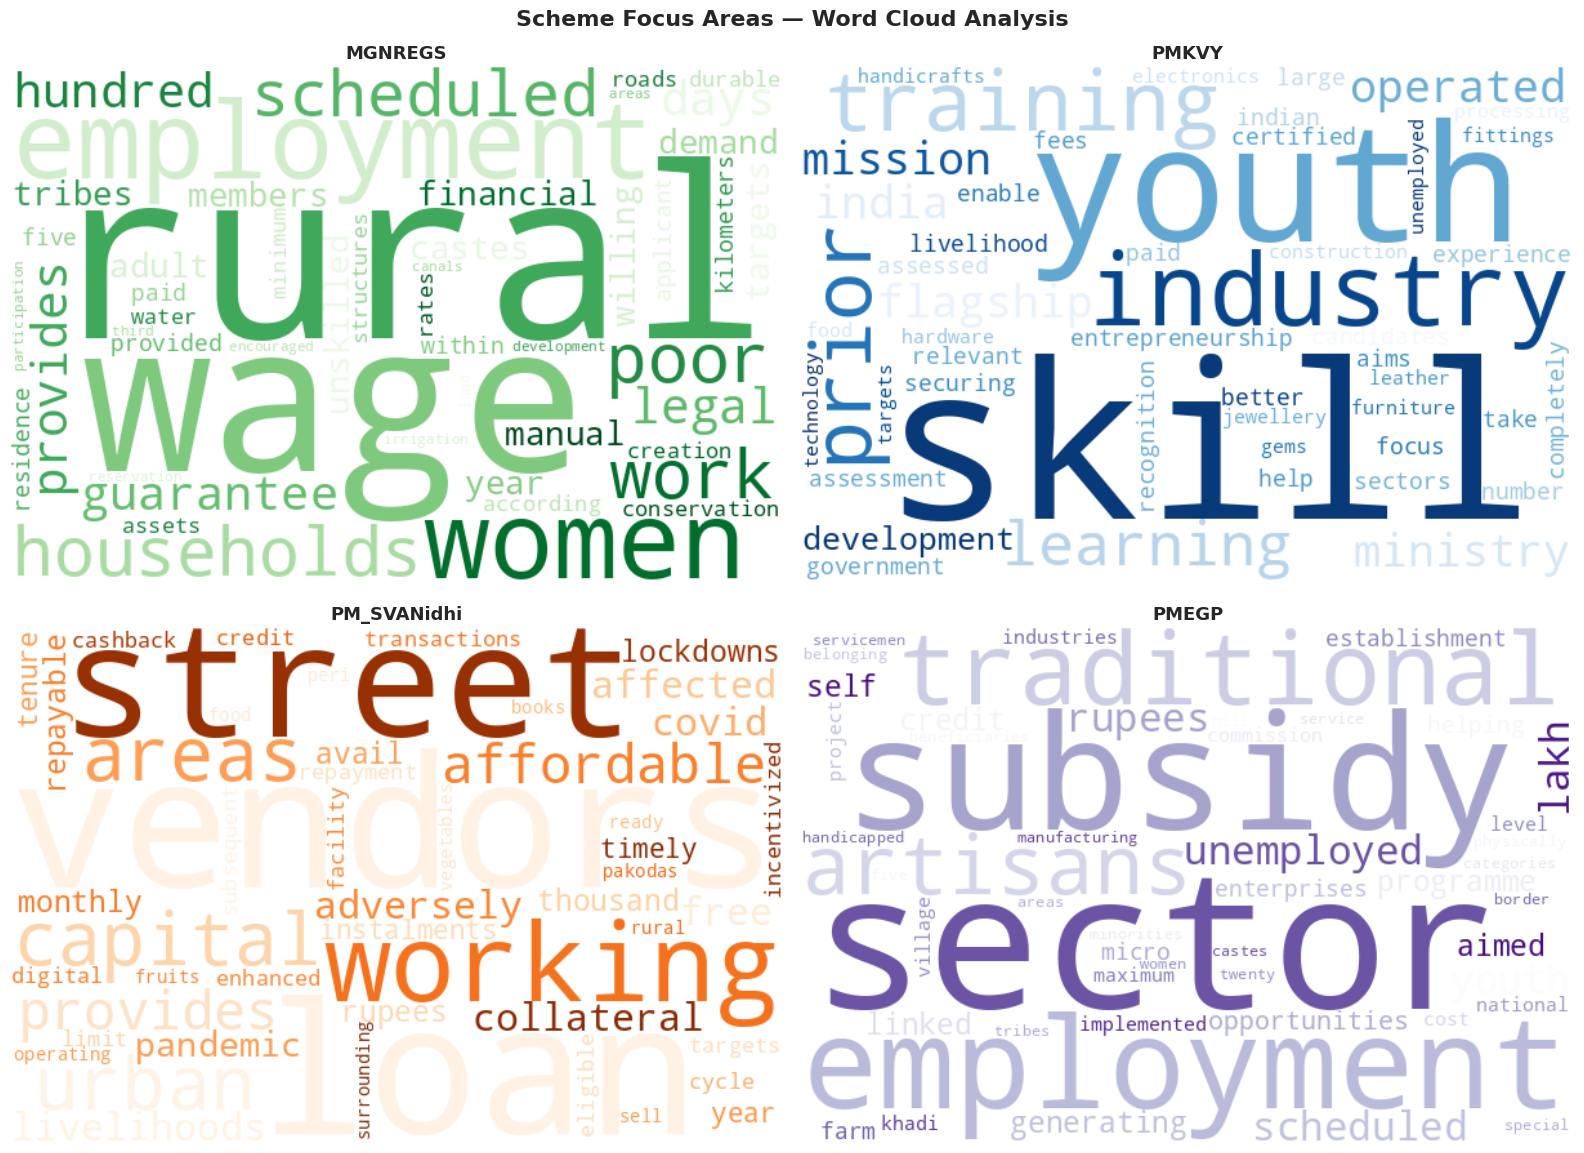

Chart 21 saved!


In [51]:
# Chart 21: Word Cloud for Each Scheme

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors_wc = ['Greens', 'Blues', 'Oranges', 'Purples']

for i, (scheme_name, tokens) in enumerate(scheme_tokens.items()):
    text_joined = ' '.join(tokens)
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colors_wc[i],
        max_words=50
    ).generate(text_joined)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{scheme_name}', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Scheme Focus Areas — Word Cloud Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_path}/chart21_scheme_wordclouds.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 21 saved!")

In [52]:
# Top Keywords Per Scheme

scheme_top_words = {}
for scheme_name, tokens in scheme_tokens.items():
    counter = Counter(tokens)
    top_10 = counter.most_common(10)
    scheme_top_words[scheme_name] = top_10
    print(f"{scheme_name}:")
    for word, count in top_10:
        print(f"   {word:<20} {count}")
    print()

MGNREGS:
   rural                4
   employment           3
   women                3
   wage                 2
   households           2
   poor                 2
   scheduled            2
   provides             1
   legal                1
   guarantee            1

PMKVY:
   skill                3
   youth                2
   industry             2
   training             2
   prior                2
   learning             2
   flagship             1
   india                1
   mission              1
   operated             1

PM_SVANidhi:
   vendors              4
   street               3
   loan                 3
   working              2
   capital              2
   urban                2
   areas                2
   provides             1
   affordable           1
   collateral           1

PMEGP:
   sector               3
   subsidy              2
   employment           2
   traditional          2
   artisans             2
   unemployed           2
   youth                2

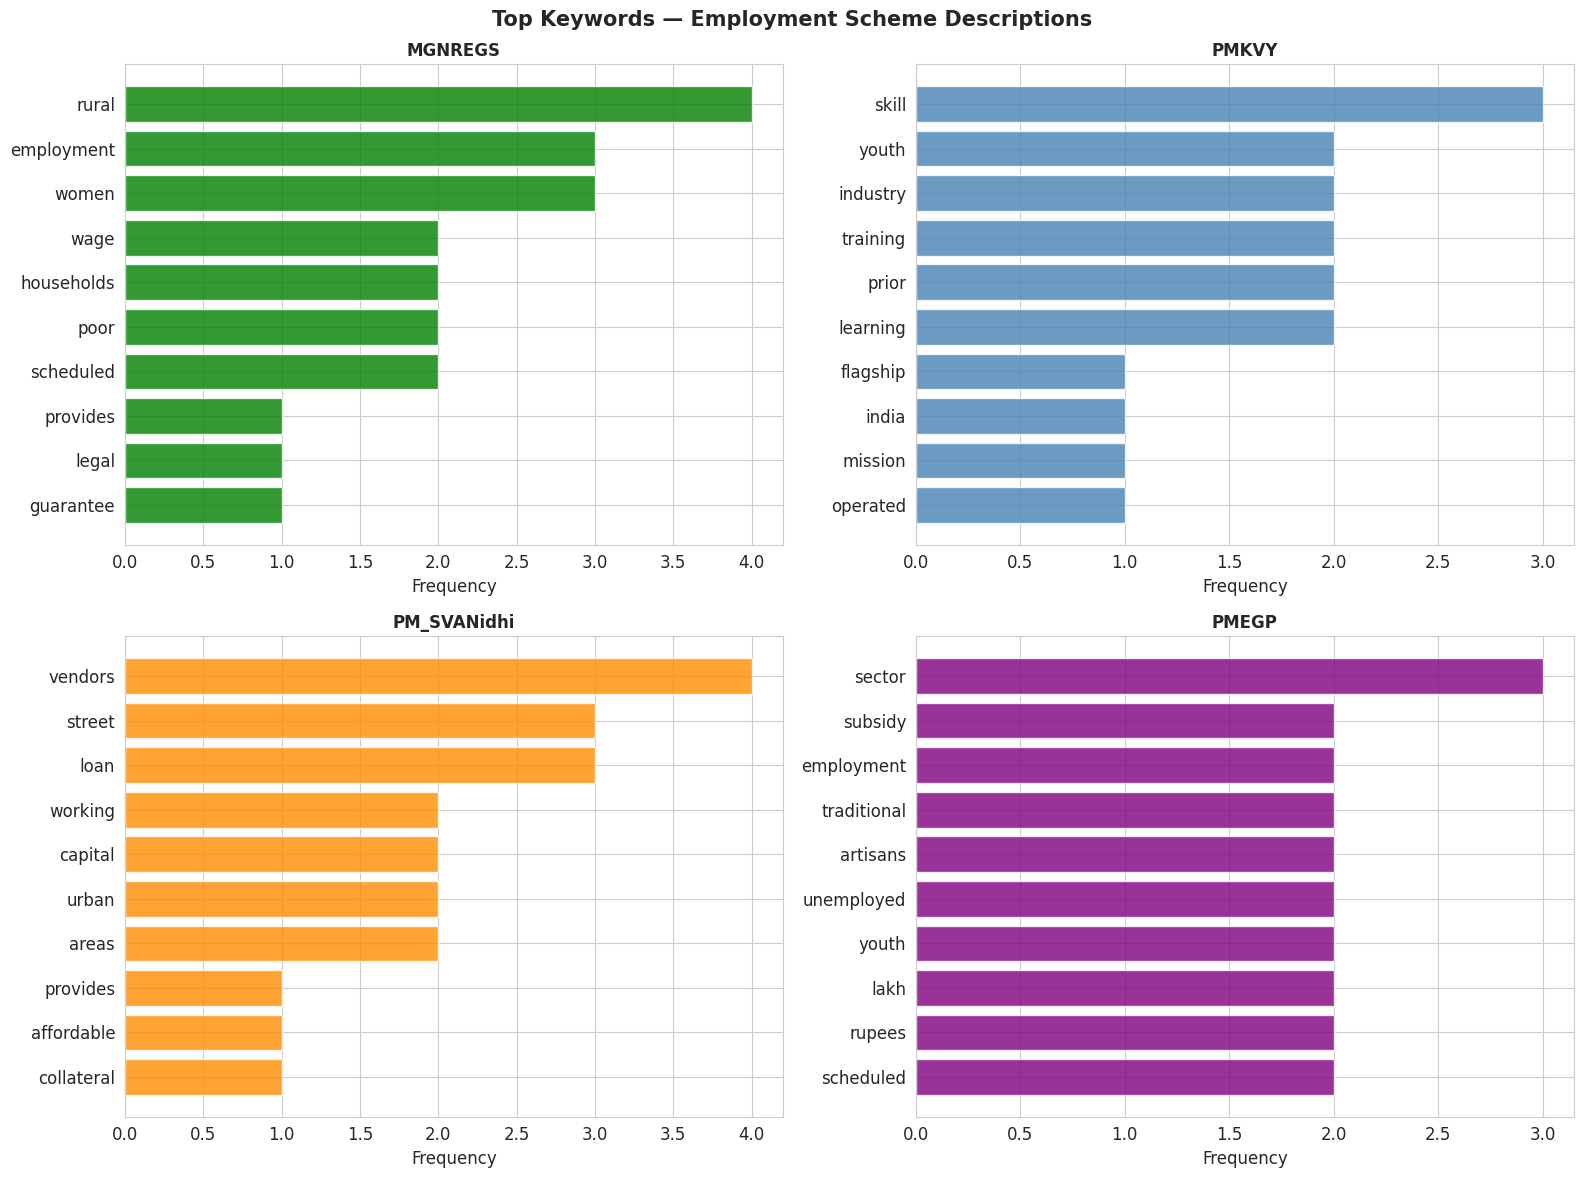

Chart 22 saved!


In [53]:
# Chart 22: Top Keywords Bar Chart Per Scheme

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

bar_colors = ['green', 'steelblue', 'darkorange', 'purple']

for i, (scheme_name, top_words) in enumerate(scheme_top_words.items()):
    words = [w[0] for w in top_words]
    counts = [w[1] for w in top_words]
    axes[i].barh(words[::-1], counts[::-1],
                 color=bar_colors[i], alpha=0.8)
    axes[i].set_title(f'{scheme_name}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Top Keywords — Employment Scheme Descriptions',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_path}/chart22_scheme_keywords.png', dpi=150)
plt.show()
print("Chart 22 saved!")

In [54]:
# Scheme Target Group Mapping

target_mapping = {
    'MGNREGS': ['Rural', 'Women', 'SC/ST', 'Unskilled Labour'],
    'PMKVY': ['Youth', 'Urban', 'Rural', 'School Dropouts', 'Unemployed'],
    'PM_SVANidhi': ['Urban', 'Street Vendors', 'Informal Workers'],
    'PMEGP': ['Rural', 'Urban', 'Artisans', 'Youth', 'SC/ST', 'Women']
}

high_unemp_states = state_cluster_data[
    state_cluster_data['Cluster_Name'] == 'High Unemployment'
]['State'].tolist()

medium_unemp_states = state_cluster_data[
    state_cluster_data['Cluster_Name'] == 'Medium Unemployment'
]['State'].tolist()

low_unemp_states = state_cluster_data[
    state_cluster_data['Cluster_Name'] == 'Low Unemployment'
]['State'].tolist()

print("High Unemployment States:", high_unemp_states)
print("Medium Unemployment States:", medium_unemp_states)
print("Low Unemployment States:", low_unemp_states)

High Unemployment States: ['Bihar', 'Chandigarh', 'Delhi', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Tripura']
Medium Unemployment States: ['Maharashtra', 'Uttar Pradesh', 'West Bengal']
Low Unemployment States: ['Andhra Pradesh', 'Assam', 'Chhattisgarh', 'Goa', 'Gujarat', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Uttarakhand']


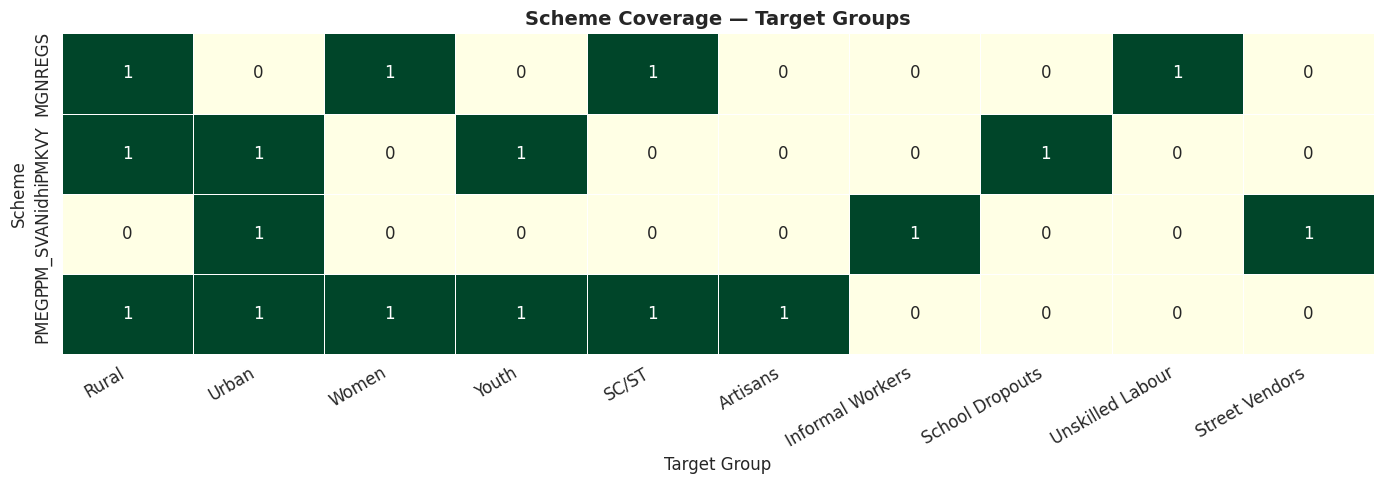

Chart 23 saved!


In [55]:
# Chart 23: Scheme Coverage Heatmap

all_groups = ['Rural', 'Urban', 'Women', 'Youth',
              'SC/ST', 'Artisans', 'Informal Workers',
              'School Dropouts', 'Unskilled Labour',
              'Street Vendors']

scheme_matrix = pd.DataFrame(0,
                              index=list(schemes.keys()),
                              columns=all_groups)

for scheme, targets in target_mapping.items():
    for group in targets:
        if group in scheme_matrix.columns:
            scheme_matrix.loc[scheme, group] = 1

plt.figure(figsize=(14,5))
sns.heatmap(scheme_matrix,
            annot=True, fmt='d',
            cmap='YlGn',
            linewidths=0.5,
            cbar=False)
plt.title('Scheme Coverage — Target Groups',
          fontsize=14, fontweight='bold')
plt.xlabel('Target Group')
plt.ylabel('Scheme')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{output_path}/chart23_scheme_coverage_heatmap.png', dpi=150)
plt.show()
print("Chart 23 saved!")

In [56]:
# Final Summary

print("=" * 50)
print("UNEMPLOYMENT ANALYSIS — SUMMARY")
print("=" * 50)
print(f"States           : {unemp['State'].nunique()}")
print(f"Period           : {unemp['Year'].min()} to {unemp['Year'].max()}")
print(f"Records          : {unemp.shape[0]}")
print(f"Avg Unemployment : {unemp['Unemployment_Rate'].mean():.2f}%")
print(f"Highest State    : {unemp.groupby('State')['Unemployment_Rate'].mean().idxmax()}")
print(f"Lowest State     : {unemp.groupby('State')['Unemployment_Rate'].mean().idxmin()}")
print(f"Rural Avg        : {unemp[unemp['Area']=='Rural']['Unemployment_Rate'].mean():.2f}%")
print(f"Urban Avg        : {unemp[unemp['Area']=='Urban']['Unemployment_Rate'].mean():.2f}%")
print(f"2019 Avg         : {unemp[unemp['Year']==2019]['Unemployment_Rate'].mean():.2f}%")
print(f"2020 Avg         : {unemp[unemp['Year']==2020]['Unemployment_Rate'].mean():.2f}%")
print(f"Best ML Model    : {best_model} — {results['Accuracy'].max():.4f}")
print(f"High Risk States : {len(high_unemp_states)}")
print(f"Medium Risk      : {len(medium_unemp_states)}")
print(f"Low Risk         : {len(low_unemp_states)}")
print(f"Schemes Analysed : {len(schemes)}")
print("=" * 50)

UNEMPLOYMENT ANALYSIS — SUMMARY
States           : 28
Period           : 2019 to 2020
Records          : 740
Avg Unemployment : 11.79%
Highest State    : Tripura
Lowest State     : Meghalaya
Rural Avg        : 10.32%
Urban Avg        : 13.17%
2019 Avg         : 9.40%
2020 Avg         : 15.10%
Best ML Model    : Random Forest — 0.7297
High Risk States : 8
Medium Risk      : 3
Low Risk         : 17
Schemes Analysed : 4


In [57]:
import joblib
import os

# Save models
joblib.dump(lr, f'{output_path}/model_logistic_regression.pkl')
joblib.dump(rf, f'{output_path}/model_random_forest.pkl')
joblib.dump(xgb, f'{output_path}/model_xgboost.pkl')

# Save CSVs
results.to_csv(f'{output_path}/model_comparison_results.csv', index=False)
state_cluster_data.to_csv(f'{output_path}/state_clusters.csv', index=False)
merged_analysis.to_csv(f'{output_path}/mgnregs_unemployment_merged.csv', index=False)
scheme_matrix.to_csv(f'{output_path}/scheme_coverage_matrix.csv')

print("All files saved!")
print(f"\nTotal output files: {len(os.listdir(output_path))}")
print("\nAll files:")
for f in sorted(os.listdir(output_path)):
    print(f"  ✅ {f}")

All files saved!

Total output files: 30

All files:
  ✅ chart10_mgnregs_expenditure.png
  ✅ chart11_women_participation.png
  ✅ chart12_avg_wage.png
  ✅ chart13_scheme_reach.png
  ✅ chart14_india_global_trend.png
  ✅ chart15_model_accuracy.png
  ✅ chart16_confusion_matrix.png
  ✅ chart17_feature_importance.png
  ✅ chart18_elbow_method.png
  ✅ chart19_state_clusters.png
  ✅ chart1_top10_states_unemployment.png
  ✅ chart20_mgnregs_vs_unemployment.png
  ✅ chart21_scheme_wordclouds.png
  ✅ chart22_scheme_keywords.png
  ✅ chart23_scheme_coverage_heatmap.png
  ✅ chart2_lowest_unemployment_states.png
  ✅ chart3_rural_vs_urban.png
  ✅ chart4_monthly_trend.png
  ✅ chart5_statewise_rural_urban.png
  ✅ chart6_labour_participation.png
  ✅ chart7_unemployment_distribution.png
  ✅ chart8_correlation_heatmap.png
  ✅ chart9_covid_impact.png
  ✅ mgnregs_unemployment_merged.csv
  ✅ model_comparison_results.csv
  ✅ model_logistic_regression.pkl
  ✅ model_random_forest.pkl
  ✅ model_xgboost.pkl
  ✅ schem